# Week 1 · Task 4 — Vector projection, checked against geometry

**Roadmap task:** *Implement vector projection and check it against the geometric formula.*

**What this notebook shows**

1. The derivation of the projection formula on "paper" (you should redo it by hand).
2. An implementation using only the dot product.
3. An **independent** check that uses only lengths and angles — no dot product at all.
4. Three properties that prove it is really a projection.
5. Why this matters later: cosine similarity, and linear regression (Week 9) *is* a projection.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from mathkit.linalg import project, project_geometric_2d, projection_matrix, scalar_projection

FIG = pathlib.Path("figures"); FIG.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
np.set_printoptions(suppress=True, precision=4)

## 1. Derivation — do this on paper first

**In simple words:** shine a light straight down onto the line through $\vec b$. The shadow of $\vec a$ is the projection.

1. The shadow lies on the line through $\vec b$, so it equals $c\,\vec b$ for some number $c$.
2. The leftover piece $\vec r = \vec a - c\,\vec b$ must be **perpendicular** to $\vec b$ (the light shines straight down), so $\vec b\cdot\vec r = 0$.
3. Expand: $\vec b\cdot\vec a - c\,(\vec b\cdot\vec b) = 0 \;\Rightarrow\; c = \dfrac{\vec a\cdot\vec b}{\vec b\cdot\vec b}$.

$$\boxed{\;\text{proj}_{\vec b}\,\vec a = \frac{\vec a\cdot\vec b}{\vec b\cdot\vec b}\,\vec b\;}$$

**The geometric version** (what the dot product *means*): the shadow's signed length is $\|\vec a\|\cos\theta$, pointing along the unit vector $\hat b = \vec b/\|\vec b\|$:

$$\text{proj}_{\vec b}\,\vec a = \|\vec a\|\cos\theta\;\hat b$$

These two agree only because $\vec a\cdot\vec b = \|\vec a\|\,\|\vec b\|\cos\theta$. Checking them against each other in code is therefore a check of that identity.

## 2. A worked example by hand

$\vec a = (3, 4)$, $\vec b = (4, 0)$ (along the x-axis):
$\vec a\cdot\vec b = 12$, $\vec b\cdot\vec b = 16$, so $c = 0.75$ and the projection is $0.75\cdot(4,0) = (3, 0)$. Obvious: the shadow of $(3,4)$ on the x-axis is $(3,0)$.

In [2]:
a, b = np.array([3.0, 4.0]), np.array([4.0, 0.0])
print("dot-product formula :", project(a, b))
print("geometric formula   :", project_geometric_2d(a, b))
print("scalar projection   :", scalar_projection(a, b), "  (= |a| cos θ = 5 · 3/5)")

dot-product formula : [3. 0.]
geometric formula   : [3. 0.]
scalar projection   : 3.0   (= |a| cos θ = 5 · 3/5)


## 3. Check against geometry on 10,000 random pairs

`project_geometric_2d` computes each vector's angle with `atan2`, subtracts them to get $\theta$, and uses $\|\vec a\|\cos\theta$ — **no dot product anywhere**. If the two methods agree everywhere, the dot-product formula is right.

In [3]:
rng = np.random.default_rng(0)
max_err = 0.0
for _ in range(10_000):
    a, b = rng.normal(size=2) * 5, rng.normal(size=2) * 5
    max_err = max(max_err, np.max(np.abs(project(a, b) - project_geometric_2d(a, b))))
print(f"largest disagreement over 10,000 random pairs: {max_err:.2e}   (floating-point noise only)")

largest disagreement over 10,000 random pairs: 1.03e-14   (floating-point noise only)


## 4. See it

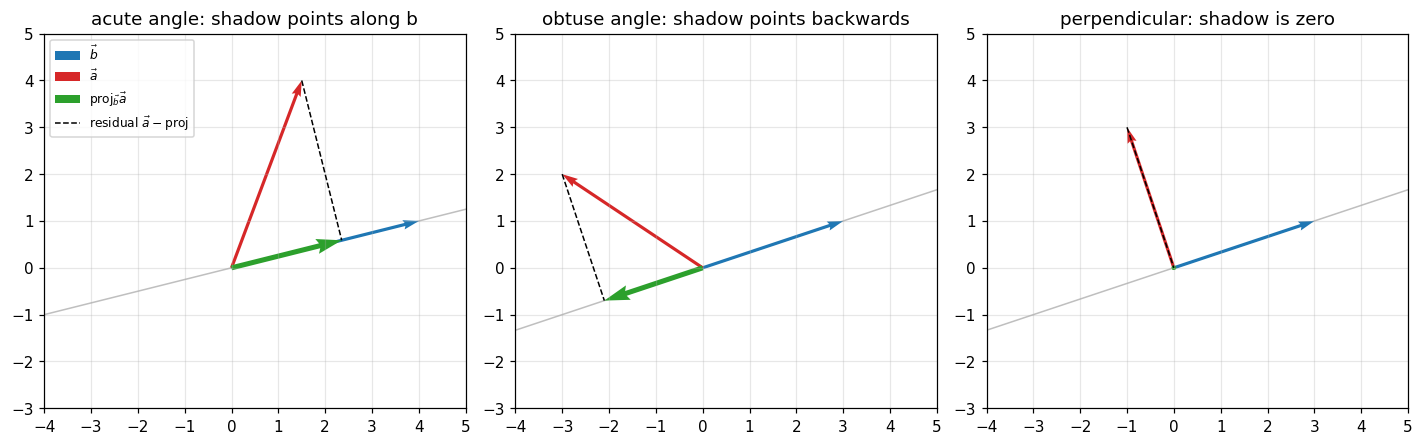

In [4]:
def draw(ax, a, b, title):
    p = project(a, b)
    t = np.linspace(-1.6, 1.6, 2)
    ax.plot(t * b[0] * 1.2, t * b[1] * 1.2, color="0.75", lw=1, zorder=0)      # the line through b
    ax.quiver(0, 0, *b, angles="xy", scale_units="xy", scale=1, color="tab:blue", label=r"$\vec b$")
    ax.quiver(0, 0, *a, angles="xy", scale_units="xy", scale=1, color="tab:red", label=r"$\vec a$")
    ax.quiver(0, 0, *p, angles="xy", scale_units="xy", scale=1, color="tab:green", width=0.012,
              label=r"proj$_{\vec b}\vec a$")
    ax.plot([a[0], p[0]], [a[1], p[1]], "k--", lw=1, label=r"residual $\vec a - $proj")
    ax.set_aspect("equal"); ax.set_xlim(-4, 5); ax.set_ylim(-3, 5); ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))
draw(axes[0], np.array([1.5, 4.0]), np.array([4.0, 1.0]), "acute angle: shadow points along b")
draw(axes[1], np.array([-3.0, 2.0]), np.array([3.0, 1.0]), "obtuse angle: shadow points backwards")
draw(axes[2], np.array([-1.0, 3.0]), np.array([3.0, 1.0]), "perpendicular: shadow is zero")
axes[0].legend(loc="upper left", fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "w1_projection.png", dpi=150); plt.show()

## 5. Three properties that prove it really is a projection

1. **The residual is perpendicular to $\vec b$** — that was our starting assumption.
2. **It is the closest point on the line** to $\vec a$ — every other point $c\,\vec b$ is further away. This is exactly the idea behind *least squares*.
3. **Projecting twice changes nothing.** As a matrix: $P = \dfrac{\vec b\,\vec b^{\!\top}}{\vec b^{\!\top}\vec b}$ satisfies $P^2 = P$, $P^\top = P$, and $\text{rank}(P)=1$ (it squashes the whole plane onto one line — so it has **no inverse**: you cannot recover $\vec a$ from its shadow).

In [5]:
a, b = rng.normal(size=4), rng.normal(size=4)     # works in any dimension, not just 2D
p = project(a, b)
print("1) residual · b          =", (a - p) @ b)

cs = np.linspace(-3, 3, 601)
dists = [np.linalg.norm(a - c * b) for c in cs]
c_best = cs[int(np.argmin(dists))]
print(f"2) brute-force best c    = {c_best:.3f}   formula c = {(a @ b) / (b @ b):.3f}")

P = projection_matrix(b)
print("3) P@P == P ?", np.allclose(P @ P, P), "| symmetric ?", np.allclose(P, P.T),
      "| rank =", np.linalg.matrix_rank(P), "| det =", round(np.linalg.det(P), 12))

1) residual · b          = -5.023340540310681e-18
2) brute-force best c    = -0.100   formula c = -0.099
3) P@P == P ? True | symmetric ? True | rank = 1 | det = 0.0


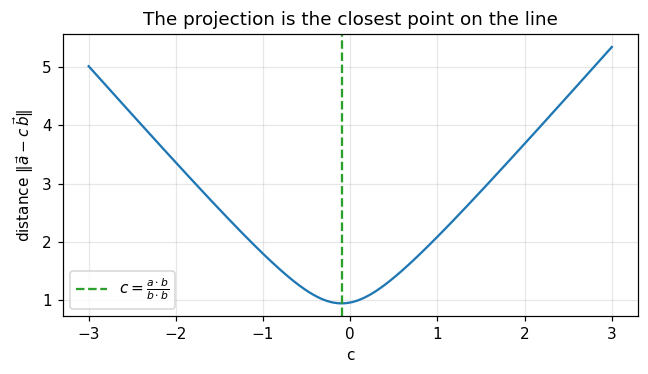

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(cs, dists)
ax.axvline((a @ b) / (b @ b), color="tab:green", ls="--", label=r"$c = \frac{a\cdot b}{b\cdot b}$")
ax.set_xlabel("c"); ax.set_ylabel(r"distance $\|\vec a - c\,\vec b\|$")
ax.set_title("The projection is the closest point on the line"); ax.legend()
fig.tight_layout(); fig.savefig(FIG / "w1_projection_closest.png", dpi=150); plt.show()

## 6. Why a data scientist cares

* **Cosine similarity** — the "how similar are these two things" number used for text embeddings, recommendations and retrieval (Week 28) — is just the dot product of the two unit vectors: $\cos\theta = \dfrac{\vec a\cdot\vec b}{\|\vec a\|\,\|\vec b\|}$.
* **Linear regression is a projection.** In Week 9 you will project the target vector $\vec y$ onto the space spanned by the feature columns. The "residuals" are the dashed line above; "least squares" is property 2. Same picture, more dimensions.
* **Norms.** $\|\vec x\|_2 = \sqrt{\sum x_i^2}$ (straight-line length) and $\|\vec x\|_1 = \sum |x_i|$ (city-block length). These become ridge (L2) and lasso (L1) regularisation in Week 10.

In [7]:
docs = {"cats": np.array([3, 0, 1, 0]), "kittens": np.array([2, 0, 1, 0]),
        "stocks": np.array([0, 4, 0, 2])}          # made-up word-count vectors
cos = lambda u, v: (u @ v) / (np.linalg.norm(u) * np.linalg.norm(v))
print(f"cos(cats, kittens) = {cos(docs['cats'], docs['kittens']):.3f}   <- similar")
print(f"cos(cats, stocks)  = {cos(docs['cats'], docs['stocks']):.3f}   <- unrelated (perpendicular)")
x = np.array([3.0, -4.0])
print("L2 norm of (3,-4):", np.linalg.norm(x), "  L1 norm:", np.abs(x).sum())

cos(cats, kittens) = 0.990   <- similar
cos(cats, stocks)  = 0.000   <- unrelated (perpendicular)
L2 norm of (3,-4): 5.0   L1 norm: 7.0


## 7. Your turn

1. By hand: project $\vec a=(2,3)$ onto $\vec b=(1,1)$. (Answer: $(2.5, 2.5)$.) Then check with `project`.
2. By hand: write the 2×2 projection matrix $P$ for $\vec b = (1,1)$ and verify $P^2=P$.
3. Why does $\det P = 0$? Explain using the 3Blue1Brown idea of "squashing space into a lower dimension".
4. **Explain out loud:** "What does the dot product measure geometrically, and why does it show up in every similarity calculation?"